In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
plt.figure(figsize=(10,6))
sns.set(style="whitegrid")

<Figure size 1000x600 with 0 Axes>

In [3]:
df = pd.read_csv("demandas.csv")

In [4]:
df.head()

,data,id_loja,id_produto,categoria,regiao,nivel_estoque,unid_vendidas,unid_pedidas,preco,desconto,condicao_climatica,promocao,preco_concorrente,sazonalidade,epidemia,demanda
0,2022-01-01,S001,P0001,Eletronicos,Norte,195,102,252,72.72,5,Nevada,0,85.73,Inverno,0,115
1,2022-01-01,S001,P0002,Roupas,Norte,117,117,249,80.16,15,Nevada,1,92.02,Inverno,0,229
2,2022-01-01,S001,P0003,Roupas,Norte,247,114,612,62.94,10,Nevada,1,60.08,Inverno,0,157
3,2022-01-01,S001,P0004,Eletronicos,Norte,139,45,102,87.63,10,Nevada,0,85.19,Inverno,0,52
4,2022-01-01,S001,P0005,Alimentos,Norte,152,65,271,54.41,0,Nevada,0,51.63,Inverno,0,59


In [5]:
df.dtypes

data                      str
id_loja                   str
id_produto                str
categoria                 str
regiao                    str
nivel_estoque           int64
unid_vendidas           int64
unid_pedidas            int64
preco                 float64
desconto                int64
condicao_climatica        str
promocao                int64
preco_concorrente     float64
sazonalidade              str
epidemia                int64
demanda                 int64
dtype: object

In [6]:
df["data"] = pd.to_datetime(df["data"])

In [7]:
df.dtypes

data                  datetime64[us]
id_loja                          str
id_produto                       str
categoria                        str
regiao                           str
nivel_estoque                  int64
unid_vendidas                  int64
unid_pedidas                   int64
preco                        float64
desconto                       int64
condicao_climatica               str
promocao                       int64
preco_concorrente            float64
sazonalidade                     str
epidemia                       int64
demanda                        int64
dtype: object

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data                76000 non-null  datetime64[us]
 1   id_loja             76000 non-null  str           
 2   id_produto          76000 non-null  str           
 3   categoria           76000 non-null  str           
 4   regiao              76000 non-null  str           
 5   nivel_estoque       76000 non-null  int64         
 6   unid_vendidas       76000 non-null  int64         
 7   unid_pedidas        76000 non-null  int64         
 8   preco               76000 non-null  float64       
 9   desconto            76000 non-null  int64         
 10  condicao_climatica  76000 non-null  str           
 11  promocao            76000 non-null  int64         
 12  preco_concorrente   76000 non-null  float64       
 13  sazonalidade        76000 non-null  str           
 14  e

In [9]:
df.isna().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
data,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
nivel_estoque,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
unid_vendidas,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
unid_pedidas,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
preco,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
desconto,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
promocao,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
preco_concorrente,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
epidemia,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
demanda,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [12]:
df.describe(include= "str").T

,count,unique,top,freq
id_loja,76000,5,S001,15200
id_produto,76000,20,P0001,3800
categoria,76000,5,Alimentos,30400
regiao,76000,4,Norte,30400
condicao_climatica,76000,4,Nublado,24360
sazonalidade,76000,4,Inverno,21000


In [13]:
df.head(2)

,data,id_loja,id_produto,categoria,regiao,nivel_estoque,unid_vendidas,unid_pedidas,preco,desconto,condicao_climatica,promocao,preco_concorrente,sazonalidade,epidemia,demanda
0,2022-01-01,S001,P0001,Eletronicos,Norte,195,102,252,72.72,5,Nevada,0,85.73,Inverno,0,115
1,2022-01-01,S001,P0002,Roupas,Norte,117,117,249,80.16,15,Nevada,1,92.02,Inverno,0,229


In [14]:
df["ano"] = df["data"].dt.year
df["mes"] = df["data"].dt.month
df["dia"] = df["data"].dt.day
df["dia_semana"] = df["data"].dt.day_name()

In [15]:
df

,data,id_loja,id_produto,categoria,regiao,nivel_estoque,unid_vendidas,unid_pedidas,preco,desconto,condicao_climatica,promocao,preco_concorrente,sazonalidade,epidemia,demanda,ano,mes,dia,dia_semana
0,2022-01-01,S001,P0001,Eletronicos,Norte,195,102,252,72.72,5,Nevada,0,85.73,Inverno,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Roupas,Norte,117,117,249,80.16,15,Nevada,1,92.02,Inverno,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Roupas,Norte,247,114,612,62.94,10,Nevada,1,60.08,Inverno,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Eletronicos,Norte,139,45,102,87.63,10,Nevada,0,85.19,Inverno,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Alimentos,Norte,152,65,271,54.41,0,Nevada,0,51.63,Inverno,0,59,2022,1,1,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Brinquedos,Norte,233,63,0,29.80,5,Nevada,0,32.23,Inverno,0,64,2024,1,30,Tuesday
75996,2024-01-30,S005,P0017,Brinquedos,Norte,137,115,141,42.92,5,Nevada,0,40.73,Inverno,0,137,2024,1,30,Tuesday
75997,2024-01-30,S005,P0018,Roupas,Norte,197,44,0,17.81,10,Nevada,0,19.41,Inverno,0,68,2024,1,30,Tuesday
75998,2024-01-30,S005,P0019,Moveis,Norte,125,58,0,151.72,0,Nevada,0,143.71,Inverno,0,84,2024,1,30,Tuesday


In [16]:
df.columns

Index(['data', 'id_loja', 'id_produto', 'categoria', 'regiao', 'nivel_estoque',
       'unid_vendidas', 'unid_pedidas', 'preco', 'desconto',
       'condicao_climatica', 'promocao', 'preco_concorrente', 'sazonalidade',
       'epidemia', 'demanda', 'ano', 'mes', 'dia', 'dia_semana'],
      dtype='str')

In [17]:
df["preco_com_desconto"] = df["preco"] * (1 - df["desconto"] / 100)

In [18]:
df.head()

,data,id_loja,id_produto,categoria,regiao,nivel_estoque,unid_vendidas,unid_pedidas,preco,desconto,...,promocao,preco_concorrente,sazonalidade,epidemia,demanda,ano,mes,dia,dia_semana,preco_com_desconto
0,2022-01-01,S001,P0001,Eletronicos,Norte,195,102,252,72.72,5,...,0,85.73,Inverno,0,115,2022,1,1,Saturday,69.084
1,2022-01-01,S001,P0002,Roupas,Norte,117,117,249,80.16,15,...,1,92.02,Inverno,0,229,2022,1,1,Saturday,68.136
2,2022-01-01,S001,P0003,Roupas,Norte,247,114,612,62.94,10,...,1,60.08,Inverno,0,157,2022,1,1,Saturday,56.646
3,2022-01-01,S001,P0004,Eletronicos,Norte,139,45,102,87.63,10,...,0,85.19,Inverno,0,52,2022,1,1,Saturday,78.867
4,2022-01-01,S001,P0005,Alimentos,Norte,152,65,271,54.41,0,...,0,51.63,Inverno,0,59,2022,1,1,Saturday,54.410


In [19]:
df["giro_de_estoque"] = df["unid_vendidas"] / df["nivel_estoque"]

In [20]:
df["giro_de_estoque"].describe()

count    75594.000000
mean         0.437580
std          0.298007
min          0.003150
25%          0.190807
50%          0.350475
75%          0.642276
max          1.000000
Name: giro_de_estoque, dtype: float64

In [21]:
df.groupby("categoria")["demanda"].agg(["mean","sum","std"]).sort_values(by = "sum", ascending=False)

,mean,sum,std
categoria,,,
Alimentos,120.976447,3677684,48.362730
Roupas,112.619737,1369456,41.022968
Moveis,73.581140,1006590,32.336141
Brinquedos,92.606955,985338,46.170390
Eletronicos,97.482018,889036,40.557859


In [22]:
df.groupby(["regiao","sazonalidade"])["demanda"].mean()

regiao  sazonalidade
Leste   Inverno         104.273571
        Outono          106.353297
        Primavera       100.168478
        Verão           115.388315
Norte   Inverno         102.017738
        Outono          103.065797
        Primavera        97.399457
        Verão           112.843750
Oeste   Inverno         100.988810
        Outono          100.165385
        Primavera        93.219293
        Verão           108.111141
Sul     Inverno         107.733095
        Outono          104.464560
        Primavera       100.328804
        Verão           115.089946
Name: demanda, dtype: float64

In [23]:
df.groupby("promocao")["demanda"].mean()

promocao
0     95.026843
1    123.269400
Name: demanda, dtype: float64

In [24]:
pd.pivot_table(df, values = "demanda", index="mes", columns="categoria", aggfunc="mean")

categoria,Alimentos,Brinquedos,Eletronicos,Moveis,Roupas
mes,,,,,
1,117.399457,94.242236,99.519022,75.690821,126.997962
2,103.522768,68.885204,84.184524,61.625992,128.966518
3,126.561694,128.273041,108.120968,84.015233,105.835685
4,105.111250,85.753571,85.916667,63.005556,106.972917
5,98.637903,71.756912,79.577957,56.036738,108.650202
6,147.772500,100.825000,106.922222,79.908333,105.670833
7,128.744355,74.366359,87.418011,66.156810,107.838710
8,149.875403,102.794931,109.733871,83.524194,107.871976
9,122.239167,102.722619,105.015278,81.854630,105.118750


In [25]:
pivot = pd.pivot_table(df, values = "demanda", index="mes", columns="categoria", aggfunc="mean")

pivot_norm = pivot / pivot.max()

<Axes: xlabel='categoria', ylabel='mes'>

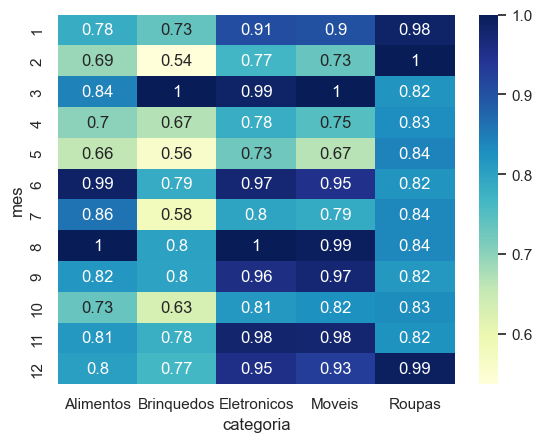

In [26]:
sns.heatmap(data= pivot_norm, annot=True, cmap="YlGnBu")

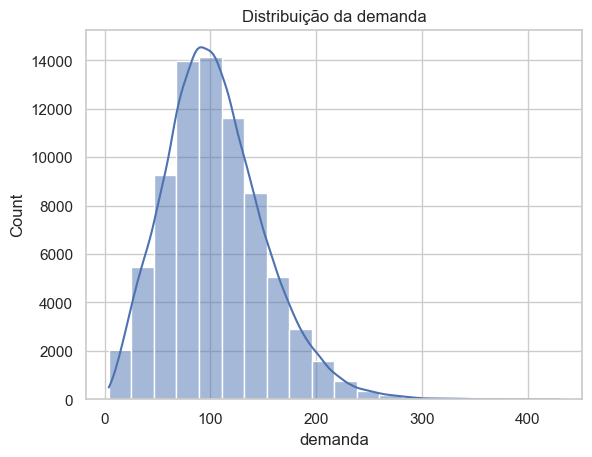

In [27]:
sns.histplot(df["demanda"], bins=20, kde=True)
plt.title("Distribuição da demanda")
plt.show()

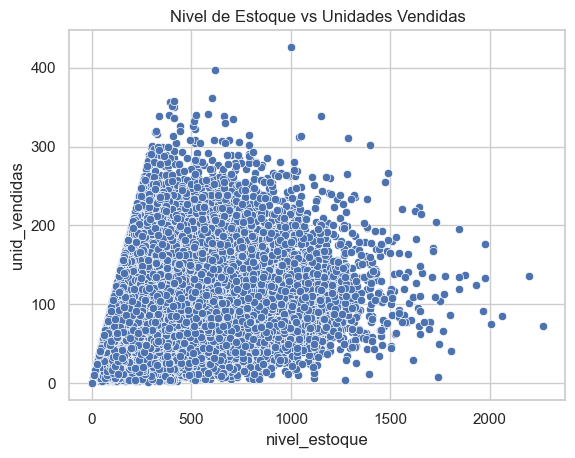

In [28]:
sns.scatterplot(data = df, x="nivel_estoque", y="unid_vendidas")
plt.title("Nivel de Estoque vs Unidades Vendidas")
plt.show()

Text(0.5, 1.0, 'Demanda por categoria')

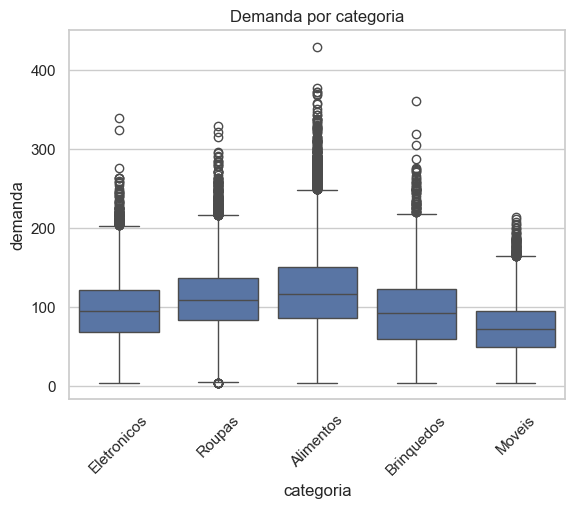

In [29]:
sns.boxplot(data=df, x="categoria", y="demanda")
plt.xticks(rotation = 45)
plt.title("Demanda por categoria")

In [30]:
df.columns

Index(['data', 'id_loja', 'id_produto', 'categoria', 'regiao', 'nivel_estoque',
       'unid_vendidas', 'unid_pedidas', 'preco', 'desconto',
       'condicao_climatica', 'promocao', 'preco_concorrente', 'sazonalidade',
       'epidemia', 'demanda', 'ano', 'mes', 'dia', 'dia_semana',
       'preco_com_desconto', 'giro_de_estoque'],
      dtype='str')

Text(0.5, 1.0, 'Demanda por condição climatica')

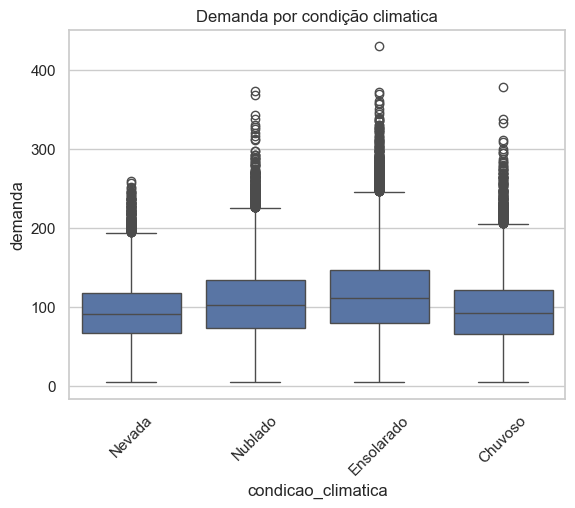

In [31]:
sns.boxplot(data=df, x="condicao_climatica", y="demanda")
plt.xticks(rotation = 45)
plt.title("Demanda por condição climatica")

In [32]:
demanda_mensal = df.groupby("mes")["demanda"].mean()
demanda_mensal

mes
1     106.040000
2      92.882500
3     113.613871
4      92.816667
5      86.521129
6     117.346000
7     101.561613
8     119.803387
9     107.431500
10     95.557258
11    107.542333
12    109.003226
Name: demanda, dtype: float64

Text(0.5, 1.0, 'Media de demandas por mês')

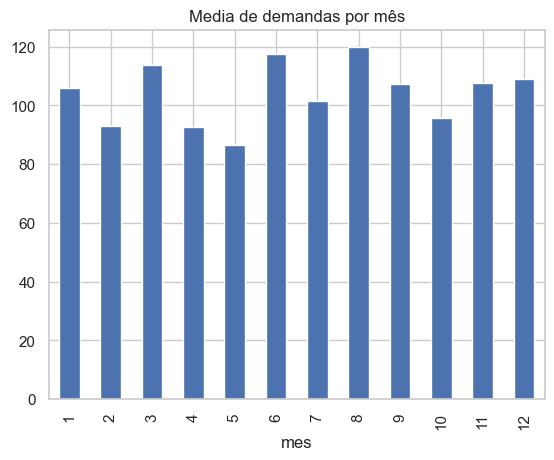

In [33]:
demanda_mensal.plot(kind= "bar")
plt.title("Media de demandas por mês")


In [34]:
demanda_diaria = df.groupby("data")["demanda"].sum()
demanda_diaria

data
2022-01-01    10060
2022-01-02    10814
2022-01-03    11317
2022-01-04    11469
2022-01-05    11724
              ...  
2024-01-26    11182
2024-01-27    11540
2024-01-28    11440
2024-01-29    10268
2024-01-30     9657
Name: demanda, Length: 760, dtype: int64

Text(0, 0.5, 'demanda')

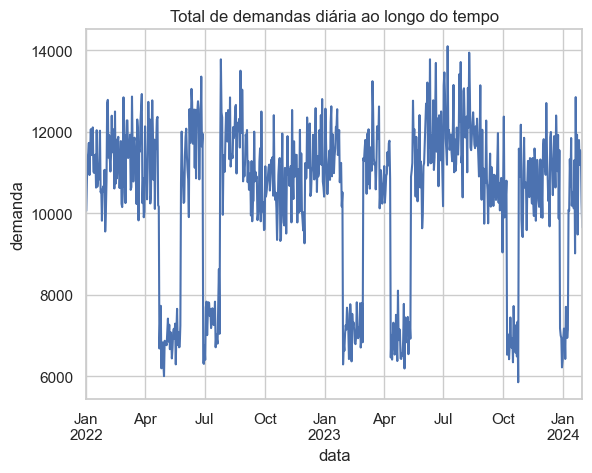

In [35]:
demanda_diaria.plot()
plt.title("Total de demandas diária ao longo do tempo")
plt.xlabel("data")
plt.ylabel("demanda")

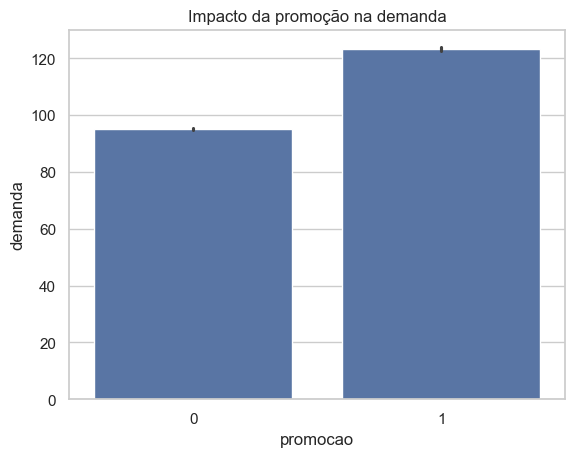

In [36]:
sns.barplot(data= df, x="promocao", y="demanda")
plt.title("Impacto da promoção na demanda")
plt.show()

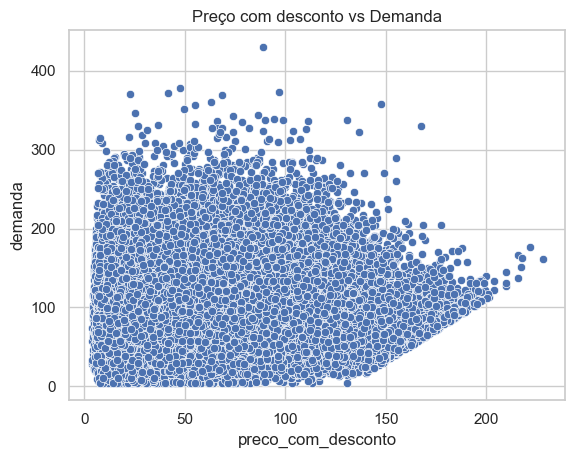

In [37]:
sns.scatterplot(data= df, x="preco_com_desconto", y="demanda"),
plt.title("Preço com desconto vs Demanda")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

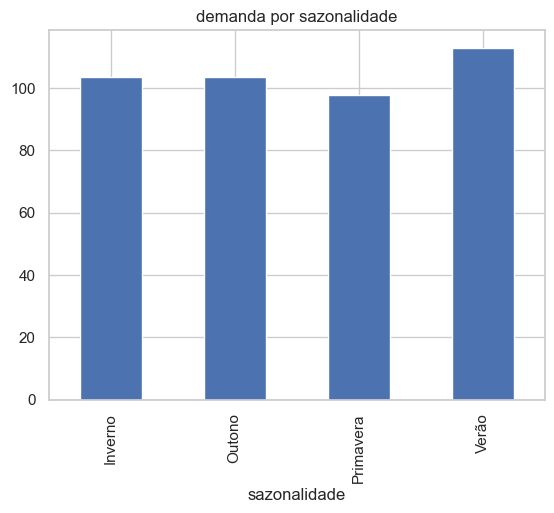

In [38]:
df.groupby("sazonalidade")["demanda"].mean().plot(kind= "bar", title="demanda por sazonalidade")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

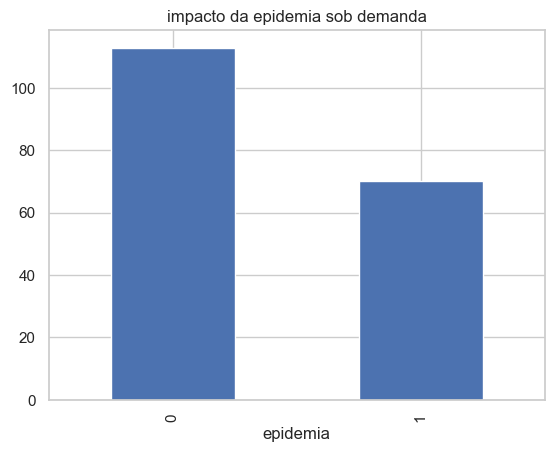

In [39]:
df.groupby("epidemia")["demanda"].mean().plot(kind= "bar", title= "impacto da epidemia sob demanda")
plt.show

In [40]:
X = df['preco_com_desconto']
y = df['demanda']

# O statsmodels precisa que você adicione uma constante para o Beta 0
X = sm.add_constant(X)

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                demanda   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     224.1
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           1.39e-50
Time:                        15:00:12   Log-Likelihood:            -4.0028e+05
No. Observations:               76000   AIC:                         8.006e+05
Df Residuals:                   75998   BIC:                         8.006e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                108.5762      0

const ($\beta_0 = 108.57$): Este é o seu ponto de partida. Se o preço fosse zero, a demanda média teórica seria de aproximadamente 108 unidades.
preco_com_desconto ($\beta_1 = -0.0689$): Este é o coeficiente de inclinação. Ele é negativo, o que faz total sentido econômico: para cada 1 real de aumento no preço, a demanda cai cerca de 0,07 unidades.

P-valor (0.000): Como o valor é menor que 0.05, esses Betas são significativos. Podemos confiar que o preço realmente afeta a demanda, mesmo que o impacto total dele sozinho seja pequeno (devido ao baixo R²

$$\text{Demanda} = 108.57 - 0.0689 \times (\text{preco\_com\_desconto})$$

In [41]:
df.dtypes

data                  datetime64[us]
id_loja                          str
id_produto                       str
categoria                        str
regiao                           str
nivel_estoque                  int64
unid_vendidas                  int64
unid_pedidas                   int64
preco                        float64
desconto                       int64
condicao_climatica               str
promocao                       int64
preco_concorrente            float64
sazonalidade                     str
epidemia                       int64
demanda                        int64
ano                            int32
mes                            int32
dia                            int32
dia_semana                       str
preco_com_desconto           float64
giro_de_estoque              float64
dtype: object

In [49]:
X = df[['promocao','nivel_estoque']]
y = df['demanda']

# O statsmodels precisa que você adicione uma constante para o Beta 0
X = sm.add_constant(X)

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                demanda   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     4049.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:17:25   Log-Likelihood:            -3.9655e+05
No. Observations:               76000   AIC:                         7.931e+05
Df Residuals:                   75997   BIC:                         7.931e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            86.9898      0.293    297.117

In [43]:
df.to_csv("preprocessamento_demanda.csv")